# Curvas de Output — EGOFET

Análisis de curvas $I_{DS}$ vs $V_{DS}$ a diferentes $V_{GS}$ constantes.
Aquí observamos las regiones lineal y de saturación del transistor.

In [1]:
# === Paso 1: Setup: imports, rutas, listar archivos ===
import os
import sys
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Para hacer 'from src import ...', Python necesita que el project root
# este en sys.path. Jupyter no lo agrega solo, asi que lo añadimos a mano.
# Truco: subimos desde CWD hasta encontrar un directorio que contenga 'src'.
# Asi funciona sin importar desde donde se haya lanzado el kernel.

def find_project_root(marker='src'):
    cwd = Path(os.getcwd()).resolve()
    for parent in [cwd, *cwd.parents]: # Va hacia atras hasta encontrar el root donde se encuentra el marker
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"No se encontro el project root con marcador '{marker}'. "
        f"Partiendo de: {cwd}"
    )

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

# importamos librerias locales de src
from src.readers.keithley_dean import list_measurements, read_curve, read_all_curves, view_measurements
from src.readers import print_structure
from src.plotting import plot_output

data_folder = PROJECT_ROOT / 'data' / 'raw'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:   {data_folder}")
print("Archivos disponibles:")
for f in sorted(os.listdir(data_folder)):
    print(f"  {f}")

Project root: /home/dibarra/Documents/egofets-project
Data folder:   /home/dibarra/Documents/egofets-project/data/raw
Archivos disponibles:
  2026-06-26_test1.hdf5
  2026-06-29_test2.1.hdf5
  2026-06-29_test2.2.hdf5
  2026-06-29_test2.hdf5
  2026-06-30_test3.hdf5
  2026-07-08_test.hdf5
  2026-07-23 TMTES PS Phototransistor v3.hdf5


In [2]:
# === Paso 2: Abrir HDF5 y listar SOLO los grupos top-level (mediciones) ===
# Cada grupo top-level es una medicion distinta (transfer, output, o stability)

hdf5_name = "2026-06-30_test3.hdf5"
hdf5_path = os.path.join(data_folder, hdf5_name)

view_measurements(hdf5_path)

Archivo: 2026-06-30_test3.hdf5
Mediciones encontradas (21):

  010626_batch1_mta1_00                               mode=transfer    curves=2
  010626_batch1_mta1_01                               mode=output      curves=7
  010626_batch1_mta1_02                               mode=desconocido  curves=0
  010626_batch1_mta1_03                               mode=transfer    curves=2
  010626_batch1_mta1_04                               mode=output      curves=7
  010626_batch1_mta1_05                               mode=desconocido  curves=0
  010626_batch2_mta1_00                               mode=transfer    curves=2
  010626_batch2_mta1_01                               mode=output      curves=7
  010626_batch2_mta1_02                               mode=transfer    curves=2
  010626_batch2_mta1_03                               mode=output      curves=7
  010626_batch3_mta1_00                               mode=transfer    curves=2
  010626_batch3_mta1_01                               mod

'  010626_batch1_mta1_00                               mode=transfer    curves=2\n  010626_batch1_mta1_01                               mode=output      curves=7\n  010626_batch1_mta1_02                               mode=desconocido  curves=0\n  010626_batch1_mta1_03                               mode=transfer    curves=2\n  010626_batch1_mta1_04                               mode=output      curves=7\n  010626_batch1_mta1_05                               mode=desconocido  curves=0\n  010626_batch2_mta1_00                               mode=transfer    curves=2\n  010626_batch2_mta1_01                               mode=output      curves=7\n  010626_batch2_mta1_02                               mode=transfer    curves=2\n  010626_batch2_mta1_03                               mode=output      curves=7\n  010626_batch3_mta1_00                               mode=transfer    curves=2\n  010626_batch3_mta1_01                               mode=output      curves=7\n  010626_batch3_mta1_02  

Barrido de $V_{DS}$ de 0 V a −0.4 V para $V_{GS}$ desde +0.2 V hasta −0.4 V. Normalmente.

In [3]:
measurement_name = "010626_batch4_mta1_04"
curve_name = "curve_000"

v_ds, i_ds = read_curve(hdf5_path, measurement_name, curve_name, curve_type="output")

dic_data = {
    "drain voltaje": v_ds,
    "current drain": i_ds
            }

df = pd.DataFrame(dic_data)
print(df) # Esto solo como ejemplo de que se pueden obtener estos datos para su graficacion

    drain voltaje  current drain
0        0.049853  -3.516670e-10
1        0.039649  -3.218650e-10
2        0.029728  -3.397460e-10
3        0.019598  -3.743170e-10
4        0.009780  -2.014640e-10
5       -0.000138  -2.586840e-10
6       -0.010035  -3.278260e-10
7       -0.019903  -2.956390e-10
8       -0.030067  -3.123280e-10
9       -0.039849  -3.576280e-10
10      -0.050027  -3.659730e-10
11      -0.059972  -3.409390e-10
12      -0.070133  -3.123280e-10
13      -0.080018  -2.646450e-10
14      -0.090094  -3.087520e-10
15      -0.099940  -3.361700e-10
16      -0.110123  -3.254410e-10
17      -0.119987  -3.242490e-10
18      -0.130143  -3.290180e-10
19      -0.139966  -3.409390e-10
20      -0.150151  -3.433230e-10
21      -0.160012  -3.516670e-10
22      -0.170181  -3.373620e-10
23      -0.180058  -3.325940e-10
24      -0.190234  -3.588200e-10
25      -0.200064  -3.707410e-10
26      -0.210195  -3.898140e-10
27      -0.220087  -4.160400e-10
28      -0.230250  -4.160400e-10
29      -0

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Output — 010626_batch4_mta1_04'}, xlabel='$V_{DS}$ (V)', ylabel='$I_{DS}$ (A)'>)

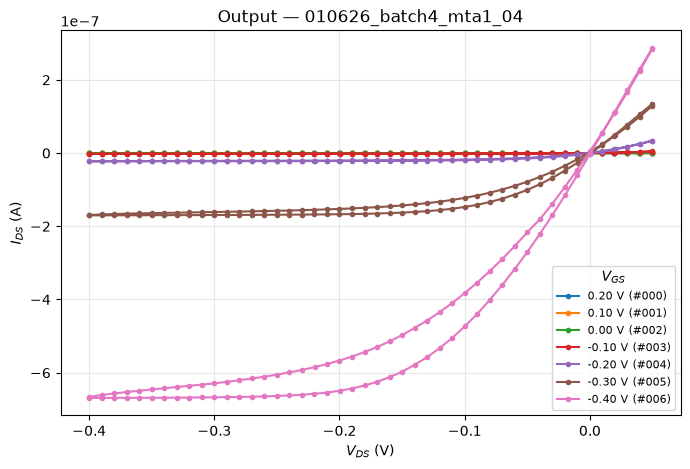

In [4]:
plot_output(hdf5_path, measurement_name)

['010626_batch1_mta1_01', '010626_batch1_mta1_04', '010626_batch2_mta1_01', '010626_batch2_mta1_03', '010626_batch3_mta1_01', '010626_batch3_mta1_04', '010626_batch4_mta1_01', '010626_batch4_mta1_04']


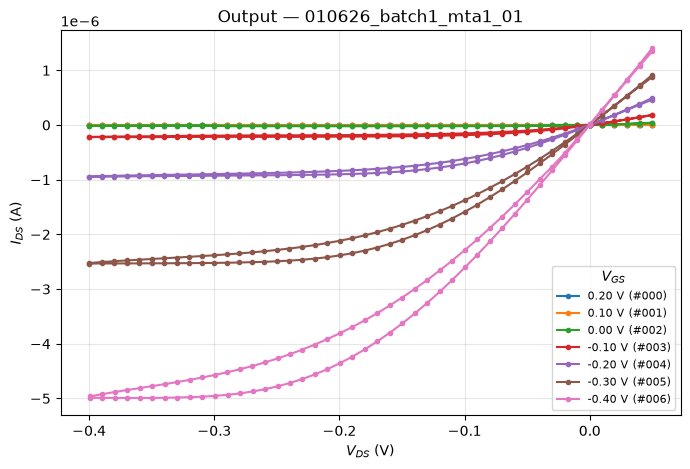

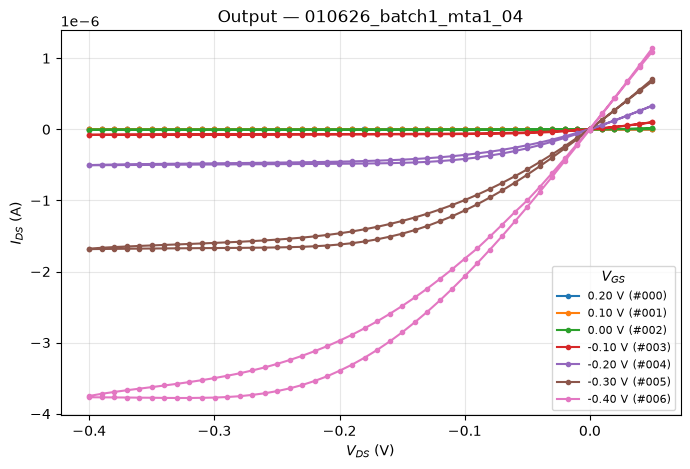

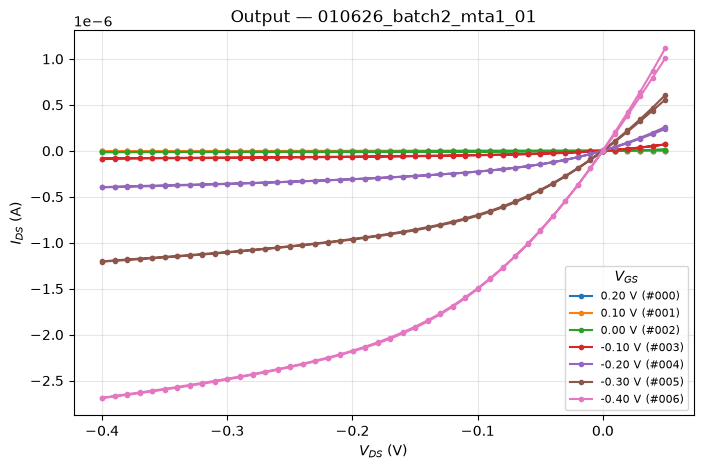

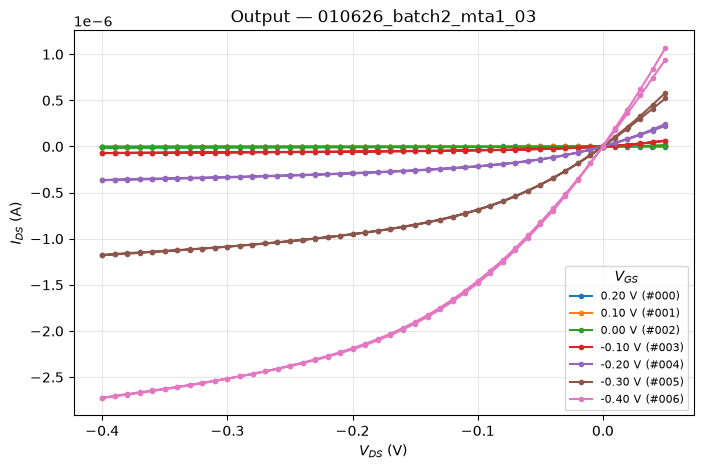

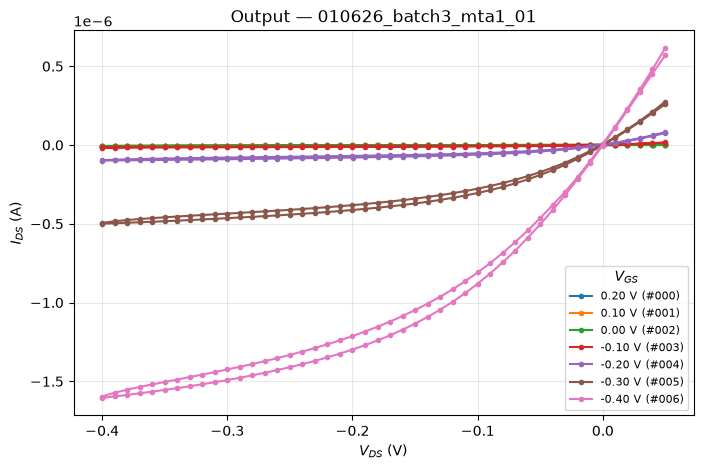

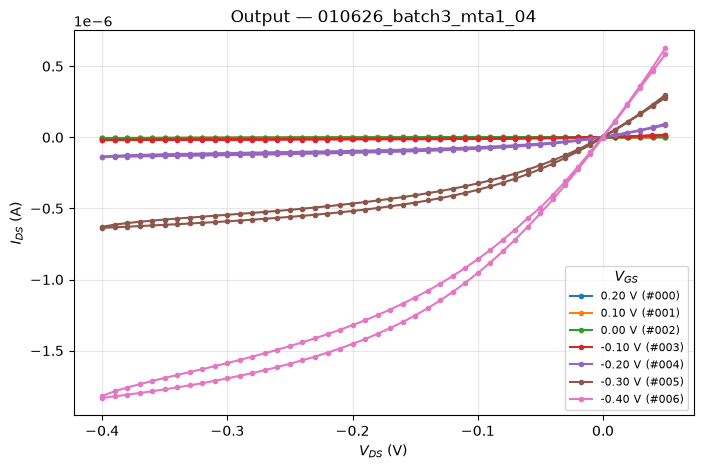

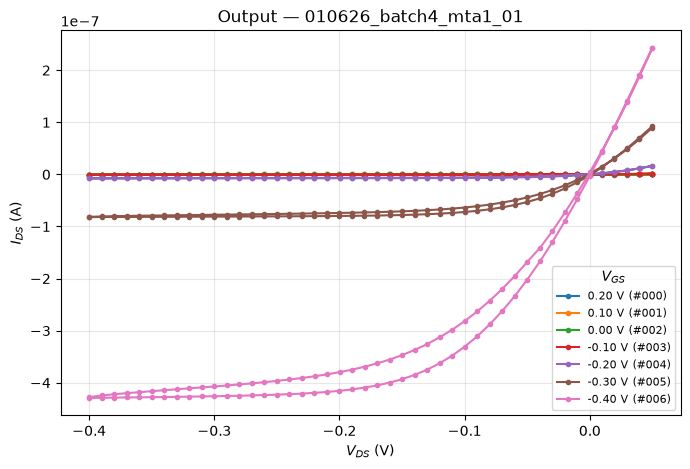

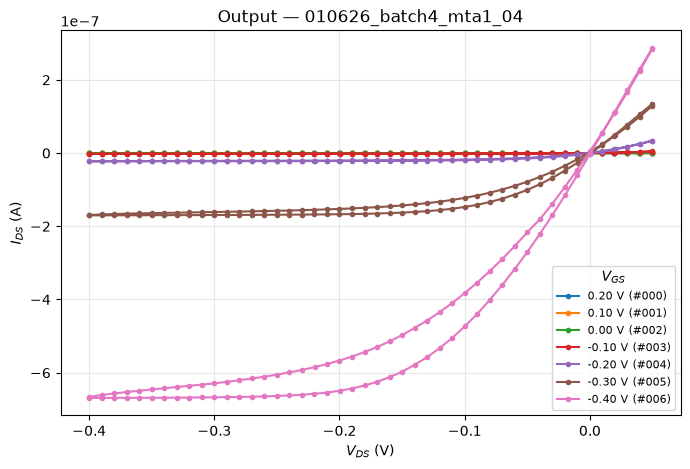

In [5]:
# === Paso 5: graficar una lista con los batch a observar ===
measurement_list_dic = list_measurements(hdf5_path)

measurement_list_names = [measurement["name"] for measurement in measurement_list_dic if measurement["mode"] == "output"]
print(measurement_list_names)

measurements_name_issue = []

for measurement_name in measurement_list_names:
    try:
        plot_output(hdf5_path, measurement_name)
    except TypeError:
        print(f"Couldn't plot {measurement_name} due to a TypeError")
        measurements_name_issue.append(measurement_name)
        continue

## Todas las curvas output

---
### Interpretación
- **Región lineal** ($V_{DS}$ pequeño): $I_{DS} \propto V_{DS}$.
- **Región de saturación** ($V_{DS}$ grande): estrangulamiento del canal.
- El incremento de $|I_{DS}|$ con $|V_{GS}|$ confirma modulación de compuerta.